# Mathematical Engineering - Financial Engineering, FY 2025-2026

# Buy Side - Exercise 4a: Statistical Arbitrage

Based on the paper "Statistical Arbitrage in the U.S. Equities Market" by Avellaneda & Lee (2008)


In [5]:
# Importing the libraries
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from utilities.backtest import backtest
from utilities.covariance_utilities import prepare_rolling_estimation_window
from utilities.statistical_arbitrage import (
    estimate_factor_model,
    estimate_all_ou_parameters,
    estimate_ou_window_residuals,
    compute_s_score,
    compute_volume_adjusted_returns,
    update_positions,
    compute_strategy_statistics,
    compute_portfolio_weights,
)

In [6]:
# Reading the data
data_path = Path("/Users/annabelli/Desktop/Financial Engineering/Labs RM BS Final/Assignment4a_BS_Group2/data") 

last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", 
    index_col="Date", 
    parse_dates=True
).ffill()

# Volume data for trading-time adjustment
volume = pd.read_csv(
    data_path / "volume.csv",
    index_col="Date",
    parse_dates=True,
)

In [7]:
performance = last_prices.pct_change().iloc[1:]

In [8]:
# Parameters
estimation_window = 1 * 252  # 2 years of data for PCA factor model estimation       ERROR
ou_estimation_window = 60  # 60 business days for O-U estimation
n_factors = 4  # Number of PCA factors     ERROR

# Trading signal parameters
s_bo = 1.25  # Buy to open threshold      ERROR
s_so = 1.25  # Sell to open threshold
s_bc = 0.50  # Buy to close threshold       ERROR
s_sc = 0.50  # Sell to close threshold

# O-U filter
min_mean_reversion_speed = 252 / 30

min_coverage = 0.95
transaction_costs = 5e-4 # ERROR

# 1. Understanding PCA-based Factor Models

The statistical arbitrage approach by Avellaneda & Lee uses Principal Component Analysis (PCA) to extract systematic risk factors from stock returns. The idea is:

1. **Factor Model**: Decompose each stock's return as:
   $$R_{i,t} = \alpha_i + \sum_{j=1}^{K} \beta_{i,j} F_{j,t} + \epsilon_{i,t}$$

   where $F_j$ are the principal component factors.

2. **Residual Returns**: The residuals $\epsilon_{i,t}$ represent the idiosyncratic (stock-specific) returns.

3. **Mean Reversion**: The cumulative residuals $X_{i,t} = \sum_{s=1}^{t} \epsilon_{i,s}$ are modeled as mean-reverting Ornstein-Uhlenbeck processes.


In [9]:
# Example: Estimate factor model on the first estimation window
calibration_date = None
for date in performance.index:
    candidate_window = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=date,
        lookback=estimation_window,
        min_coverage=min_coverage,
    )
    if candidate_window.shape[0] == estimation_window and candidate_window.shape[1] > 0:
        calibration_date = date
        calibration_window = candidate_window
        break

print(
    f"First estimation window: {calibration_window.index[0].date()} to {calibration_window.index[-1].date()}"
)
print(f"Number of observations: {len(calibration_window)}")
print(f"Number of assets: {calibration_window.shape[1]}")

First estimation window: 2013-01-03 to 2013-12-24
Number of observations: 252
Number of assets: 46


In [10]:
# Estimate the factor model
factor_model = estimate_factor_model(candidate_window, n_factors=n_factors)

print(f"Number of factors used: {factor_model['n_factors']}")
print("\nExplained variance by each factor:")
for i, ev in enumerate(factor_model["explained_variance"]):
    print(f"  PC{i + 1}: {ev:.2%}")
print(f"\nTotal explained variance: {factor_model['explained_variance'].sum():.2%}")

Number of factors used: 4

Explained variance by each factor:
  PC1: 43.08%
  PC2: 5.75%
  PC3: 3.91%
  PC4: 2.71%

Total explained variance: 55.44%


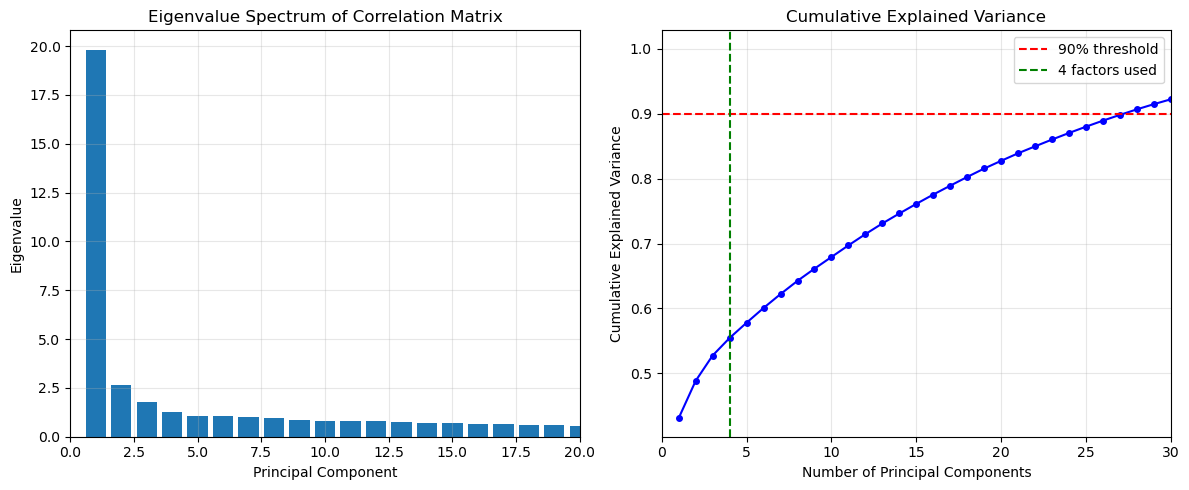

In [11]:
# Plot eigenvalue spectrum
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(factor_model["eigenvalues"]) + 1), factor_model["eigenvalues"])
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum of Correlation Matrix")
plt.xlim(0, 20)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
cumulative_var = (
    np.cumsum(factor_model["eigenvalues"]) / factor_model["eigenvalues"].sum()
)
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, "b-o", markersize=4)
plt.axhline(y=0.9, color="r", linestyle="--", label="90% threshold")
plt.axvline(x=n_factors, color="g", linestyle="--", label=f"{n_factors} factors used")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 30)

plt.tight_layout()
plt.show()

# 2. Ornstein-Uhlenbeck Process for Residuals

The cumulative residuals are modeled as an Ornstein-Uhlenbeck (O-U) process:

$$dX_t = \kappa (m - X_t) dt + \sigma dW_t$$

where:

- $\kappa$ is the **mean-reversion speed** (how fast the process reverts to the mean)
- $m$ is the **equilibrium level** (long-term mean)
- $\sigma$ is the **volatility** of the process

The **equilibrium standard deviation** is: $\sigma_{eq} = \frac{\sigma}{\sqrt{2\kappa}}$

The **half-life** of mean reversion is: $\tau_{1/2} = \frac{\ln(2)}{\kappa}$


In [12]:
# Compute cumulative residuals
cumulative_residuals = estimate_ou_window_residuals(
    candidate_window, factor_model["factors"], ou_estimation_window
)["residuals"].cumsum()

# Estimate O-U parameters
cum_residuals_ou = cumulative_residuals.iloc[-ou_estimation_window:]
ou_params = estimate_all_ou_parameters(cum_residuals_ou, dt=1 / 252)

# Display O-U parameters for a few assets
print(
    f"O-U Parameters for selected assets ({ou_estimation_window}-day window, centered means):"
)
print(f"{'Asset':<15} {'Kappa':>10} {'Half-life':>12} {'Sigma_eq':>12} {'m':>10}")
print("-" * 60)
for asset in list(ou_params.keys())[:10]:
    params = ou_params[asset]
    half_life_days = params["half_life"] * 252
    print(
        f"{asset:<15} {params['kappa']:>10.2f} {half_life_days:>10.1f} d {params['sigma_eq']:>12.4f} {params['m']:>10.4f}"
    )

O-U Parameters for selected assets (60-day window, centered means):
Asset                Kappa    Half-life     Sigma_eq          m
------------------------------------------------------------
ABI.BR               60.15        2.9 d       0.0102     0.0030
AD.AS                15.27       11.4 d       0.0308     0.0304
ADSGn.DE             16.83       10.4 d       0.0193     0.0210
AIR.PA               45.27        3.9 d       0.0239    -0.0129
AIRP.PA              28.12        6.2 d       0.0098    -0.0054
ALVG.DE              47.54        3.7 d       0.0081     0.0033
ASML.AS              19.00        9.2 d       0.0234    -0.0157
AXAF.PA              45.64        3.8 d       0.0136    -0.0079
BASFn.DE             18.33        9.5 d       0.0128     0.0141
BAYGn.DE            144.81        1.2 d       0.0073    -0.0071


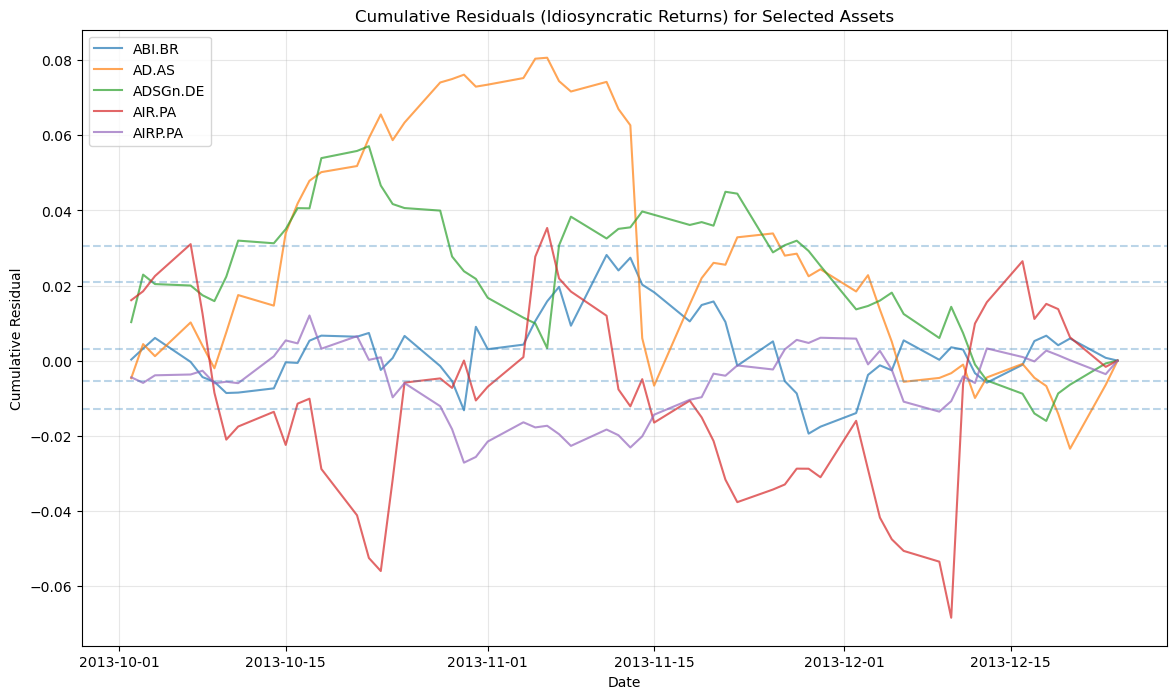

In [13]:
# Plot cumulative residuals for a few assets
sample_assets = list(cumulative_residuals.columns)[:5]

plt.figure(figsize=(14, 8))
for asset in sample_assets:
    plt.plot(
        cumulative_residuals.index, cumulative_residuals[asset], label=asset, alpha=0.7
    )
    # Add equilibrium level
    m = ou_params[asset]["m"]
    plt.axhline(y=m, linestyle="--", alpha=0.3)

plt.xlabel("Date")
plt.ylabel("Cumulative Residual")
plt.title("Cumulative Residuals (Idiosyncratic Returns) for Selected Assets")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

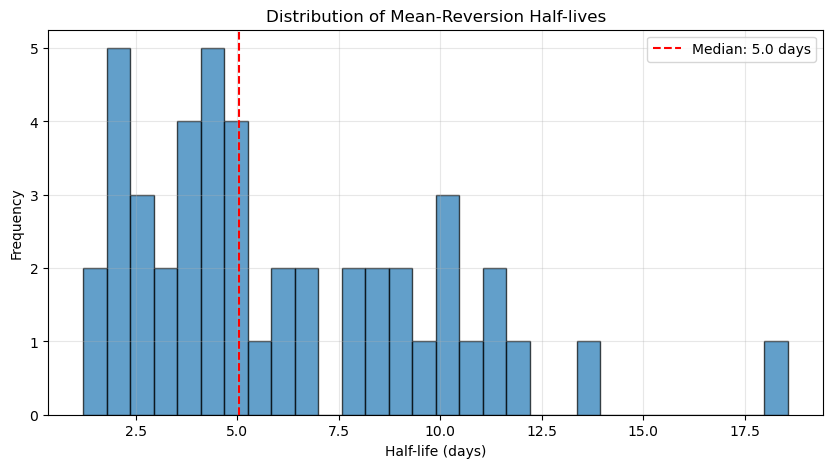

Half-life statistics:
  Mean: 6.2 days
  Median: 5.0 days
  Std: 3.8 days


In [14]:
# Distribution of half-lives
half_lives = pd.Series(
    {asset: params["half_life"] * 252 for asset, params in ou_params.items()}
)
half_lives = half_lives[half_lives < 100]  # Filter outliers

plt.figure(figsize=(10, 5))
plt.hist(half_lives, bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Half-life (days)")
plt.ylabel("Frequency")
plt.title("Distribution of Mean-Reversion Half-lives")
plt.axvline(
    half_lives.median(),
    color="r",
    linestyle="--",
    label=f"Median: {half_lives.median():.1f} days",
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Half-life statistics:")
print(f"  Mean: {half_lives.mean():.1f} days")
print(f"  Median: {half_lives.median():.1f} days")
print(f"  Std: {half_lives.std():.1f} days")

# 3. S-Score and Trading Signals

The modified **s-score** measures how far the current cumulative residual is from its equilibrium, accounting for the residual drift:

$$s_{mod, t} = s_t - \frac{\alpha}{\kappa \sigma_{eq}} =  \frac{X_t - m}{\sigma_{eq}} - \frac{\alpha}{\kappa \sigma_{eq}} $$

Trading rules:

- **Buy to Open** (enter long): $s < -s_{bo}$ (price is too low)
- **Sell to Close** (exit long): $s > -s_{bc}$ (price recovered)
- **Sell to Open** (enter short): $s > s_{so}$ (price is too high)
- **Buy to Close** (exit short): $s < s_{sc}$ (price reverted)


In [15]:
# Compute S-scores
for ticker, alpha_val in factor_model["alphas"].items():
    if ticker in ou_params:
        ou_params[ticker]["alphas"] = alpha_val

s_scores = compute_s_score(cumulative_residuals, ou_params)

# S-score summary statistics
flat = s_scores.values.flatten()
print("S-score statistics across all assets:")
print(f"  Mean: {np.nanmean(flat):.2f}")
print(f"  Std:  {np.nanstd(flat):.2f}")
print(f"  Min:  {np.nanmin(flat):.2f}")
print(f"  Max:  {np.nanmax(flat):.2f}")

S-score statistics across all assets:
  Mean: -0.00
  Std:  0.99
  Min:  -2.71
  Max:  2.94


# 4. Rolling Backtest of Statistical Arbitrage Strategy

We now implement a rolling backtest where:

1. At each trading day, we re-estimate the factor model (252-day window) and O-U parameters (60-day window)
2. We compute s-scores and update trading positions **maintaining state across days**
3. We track the portfolio performance


In [16]:
# Storage for results
all_positions    = {}
all_s_scores     = {}
all_ou_params    = {}
all_factor_models = {}

current_positions: dict[str, float] = {}

for rebalance_date in performance.index:
    estimation_window_data, diagnostics = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        diagnostics["row_count"] < estimation_window
        or estimation_window_data.shape[1] == 0
    ):
        continue

    reb_date = rebalance_date.to_pydatetime().date()
    print(f"Processing: {reb_date}")
    # 1. Estimate factor model on the 252-day window
    factor_model = estimate_factor_model(estimation_window_data, n_factors=n_factors)
    all_factor_models[reb_date] = factor_model

    # 2. Re-run OLS on the last 60 days using the 252-day PCA factors,
    #    then cumulate residuals to obtain the O-U input series X_i(t)
    cum_residuals_ou = estimate_ou_window_residuals(
        estimation_window_data, factor_model["factors"], ou_estimation_window
    )["residuals"].cumsum()

    # 3. Estimate O-U parameters on the 60-day cumulative residuals
    ou_params = estimate_all_ou_parameters(
        cum_residuals_ou, dt=1/252, center_ou_means=False
    )

    # 4. Inject factor model alphas into O-U parameter dictionaries
    #    so that compute_s_score can use them for the modified s-score (eq. 17)
    for ticker, alpha_val in factor_model["alphas"].items():
        if ticker in ou_params:
            ou_params[ticker]["alphas"] = alpha_val

    all_ou_params[reb_date] = ou_params

    # 5. Filter assets by mean-reversion speed
    valid_assets = [
        ticker for ticker, params in ou_params.items()
        if params["kappa"] > min_mean_reversion_speed
    ]

    # 6. Compute modified s-scores and store the last value (today's signal)
    cur_s_scores = compute_s_score(cum_residuals_ou, ou_params, modified=True).iloc[-1]
    all_s_scores[reb_date] = cur_s_scores

    # 7. Update positions carrying over previous day's state
    current_positions = update_positions(
        current_positions=current_positions,
        cur_s_scores=cur_s_scores,
        valid_assets=valid_assets,
        s_bo=s_bo, s_so=s_so, s_bc=s_bc, s_sc=s_sc,
    )
    all_positions[reb_date] = current_positions.copy()

Processing: 2013-12-24
Processing: 2013-12-27
Processing: 2013-12-30
Processing: 2013-12-31
Processing: 2014-01-02
Processing: 2014-01-03
Processing: 2014-01-06
Processing: 2014-01-07
Processing: 2014-01-08
Processing: 2014-01-09
Processing: 2014-01-10
Processing: 2014-01-13
Processing: 2014-01-14
Processing: 2014-01-15
Processing: 2014-01-16
Processing: 2014-01-17
Processing: 2014-01-20
Processing: 2014-01-21
Processing: 2014-01-22
Processing: 2014-01-23
Processing: 2014-01-24
Processing: 2014-01-27
Processing: 2014-01-28
Processing: 2014-01-29
Processing: 2014-01-30
Processing: 2014-01-31
Processing: 2014-02-03
Processing: 2014-02-04
Processing: 2014-02-05
Processing: 2014-02-06
Processing: 2014-02-07
Processing: 2014-02-10
Processing: 2014-02-11
Processing: 2014-02-12
Processing: 2014-02-13
Processing: 2014-02-14
Processing: 2014-02-17
Processing: 2014-02-18
Processing: 2014-02-19
Processing: 2014-02-20
Processing: 2014-02-21
Processing: 2014-02-24
Processing: 2014-02-25
Processing:

In [17]:
# Build portfolio weights time series
positions_df = pd.DataFrame(all_positions).T
positions_df.index = pd.to_datetime(positions_df.index)
positions_df = positions_df.fillna(0)

# Equal weight among active positions
weights = compute_portfolio_weights(positions_df)

print("Position statistics:")
print(f"  Total rebalance dates: {len(positions_df)}")
print(
    f"  Average number of long positions: {(positions_df > 0).sum(axis=1).mean():.1f}"
)
print(
    f"  Average number of short positions: {(positions_df < 0).sum(axis=1).mean():.1f}"
)
print(f"  Average total positions: {(positions_df != 0).sum(axis=1).mean():.1f}")

Position statistics:
  Total rebalance dates: 2347
  Average number of long positions: 8.9
  Average number of short positions: 9.1
  Average total positions: 18.0


In [18]:
# Backtest the strategy
cumulative_returns = backtest(weights, performance)
cumulative_returns_with_costs = backtest(
    weights, performance, transaction_costs=transaction_costs
)

# Compute strategy statistics
stats = compute_strategy_statistics(cumulative_returns.dropna())

print("Strategy Performance:")
print(f"  Total Return: {stats['total_return']:.2%}")
print(f"  Annualized Return: {stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio: {stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown: {stats['max_drawdown']:.2%}")

Strategy Performance:
  Total Return: 49.23%
  Annualized Return: 4.40%
  Annualized Volatility: 6.06%
  Sharpe Ratio: 0.73
  Maximum Drawdown: -11.59%


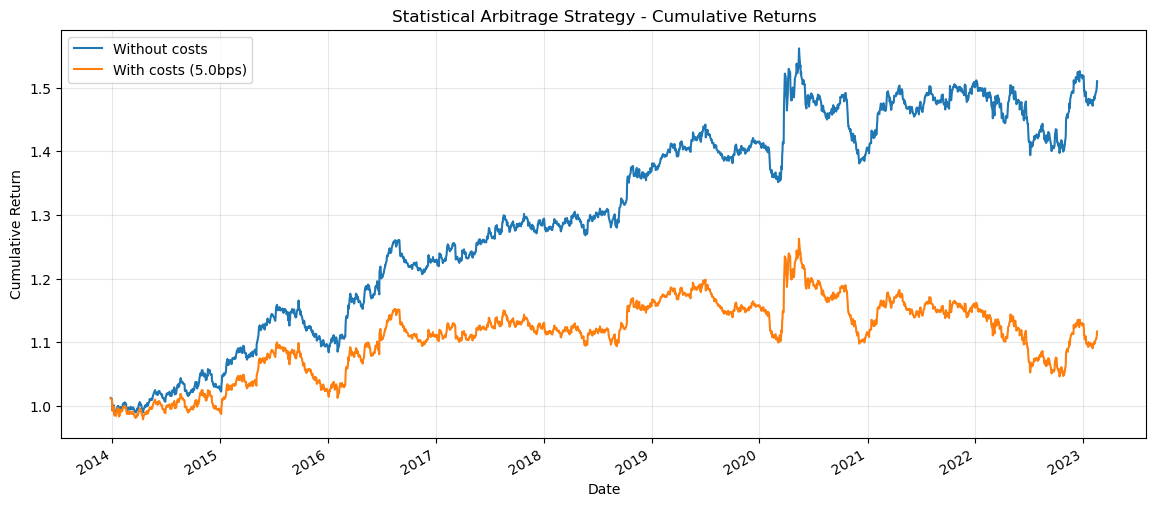

In [19]:
# Plot cumulative returns
plt.figure(figsize=(14, 6))
cumulative_returns.plot(label="Without costs", linewidth=1.5)
cumulative_returns_with_costs.plot(
    label=f"With costs ({transaction_costs * 1e4:.1f}bps)", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

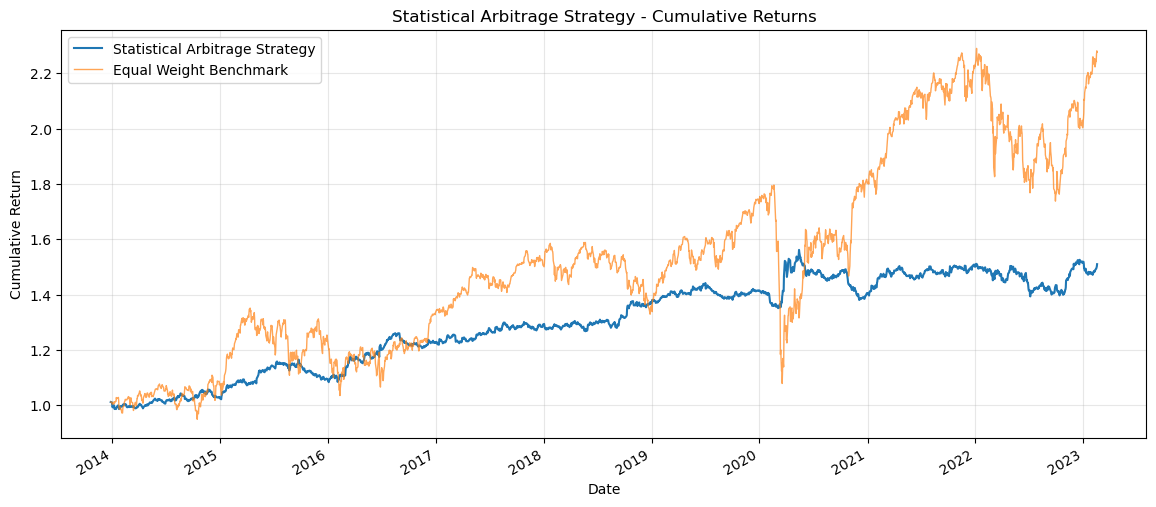

In [20]:
# Plot cumulative returns
plt.figure(figsize=(14, 6))
cumulative_returns.plot(label="Statistical Arbitrage Strategy", linewidth=1.5)

# Add benchmark (equal-weighted portfolio)
equal_weight_benchmark = (1 + performance.mean(axis=1)).cumprod()
equal_weight_benchmark = equal_weight_benchmark.reindex(
    cumulative_returns.index
).ffill()
equal_weight_benchmark = (
    equal_weight_benchmark / equal_weight_benchmark.iloc[0] * cumulative_returns.iloc[0]
)
equal_weight_benchmark.plot(label="Equal Weight Benchmark", linewidth=1, alpha=0.7)


plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Statistical Arbitrage Strategy - Cumulative Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

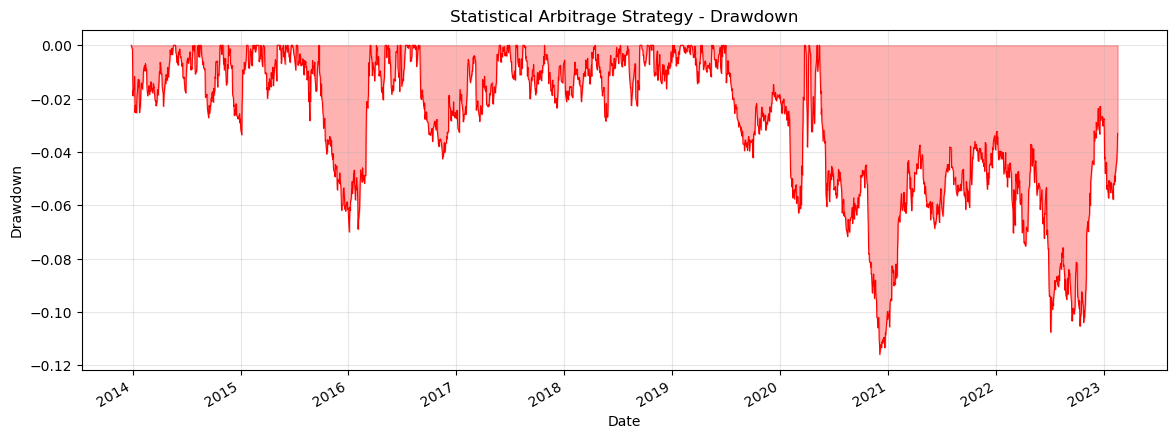

In [21]:
# Plot drawdown
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - rolling_max) / rolling_max

plt.figure(figsize=(14, 5))
drawdown.plot(color="red", linewidth=0.8)
plt.fill_between(drawdown.index, 0, drawdown.values, color="red", alpha=0.3)
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title("Statistical Arbitrage Strategy - Drawdown")
plt.grid(alpha=0.3)
plt.show()

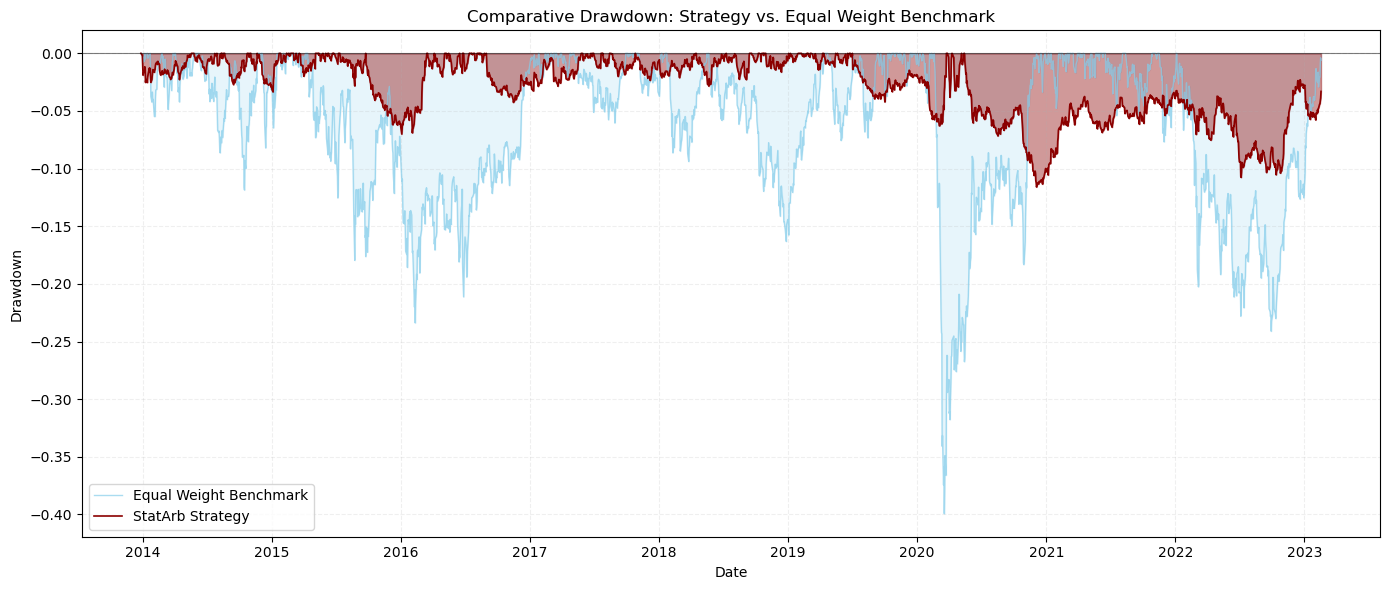

In [22]:
# Drawdown: strategy
strategy_rolling_max = cumulative_returns.cummax()
strategy_drawdown    = (cumulative_returns - strategy_rolling_max) / strategy_rolling_max

# Drawdown: equal-weight benchmark
benchmark_rolling_max = equal_weight_benchmark.cummax()
benchmark_drawdown    = (equal_weight_benchmark - benchmark_rolling_max) / benchmark_rolling_max

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(benchmark_drawdown.index, benchmark_drawdown,
        color="skyblue", label="Equal Weight Benchmark", linewidth=1, alpha=0.7)
ax.fill_between(benchmark_drawdown.index, 0, benchmark_drawdown,
                color="skyblue", alpha=0.2)

ax.plot(strategy_drawdown.index, strategy_drawdown,
        color="darkred", label="StatArb Strategy", linewidth=1.2)
ax.fill_between(strategy_drawdown.index, 0, strategy_drawdown,
                color="darkred", alpha=0.4)

ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.set_title("Comparative Drawdown: Strategy vs. Equal Weight Benchmark")
ax.legend(loc="lower left")
ax.grid(alpha=0.2, linestyle="--")

plt.tight_layout()
plt.show()

# 5. Analysis of Strategy Characteristics


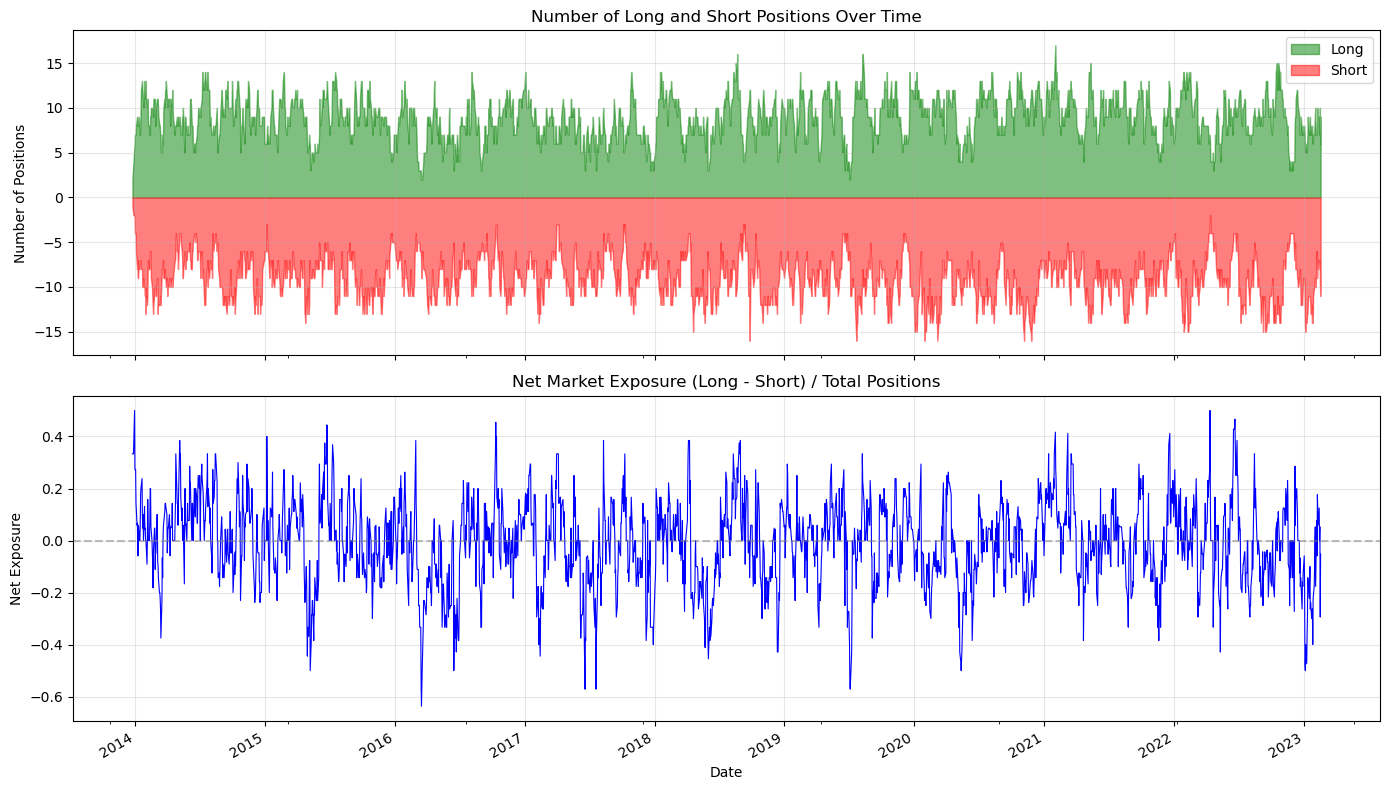

In [23]:
# Number of positions over time
n_long = (positions_df > 0).sum(axis=1)
n_short = (positions_df < 0).sum(axis=1)
n_total = (positions_df != 0).sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
ax1.fill_between(n_long.index, 0, n_long.values, color="green", alpha=0.5, label="Long")
ax1.fill_between(
    n_short.index, 0, -n_short.values, color="red", alpha=0.5, label="Short"
)
ax1.set_ylabel("Number of Positions")
ax1.set_title("Number of Long and Short Positions Over Time")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
net_exposure = positions_df.sum(axis=1) / n_total.replace(0, np.nan)
net_exposure.plot(ax=ax2, color="blue", linewidth=0.8)
ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylabel("Net Exposure")
ax2.set_xlabel("Date")
ax2.set_title("Net Market Exposure (Long - Short) / Total Positions")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

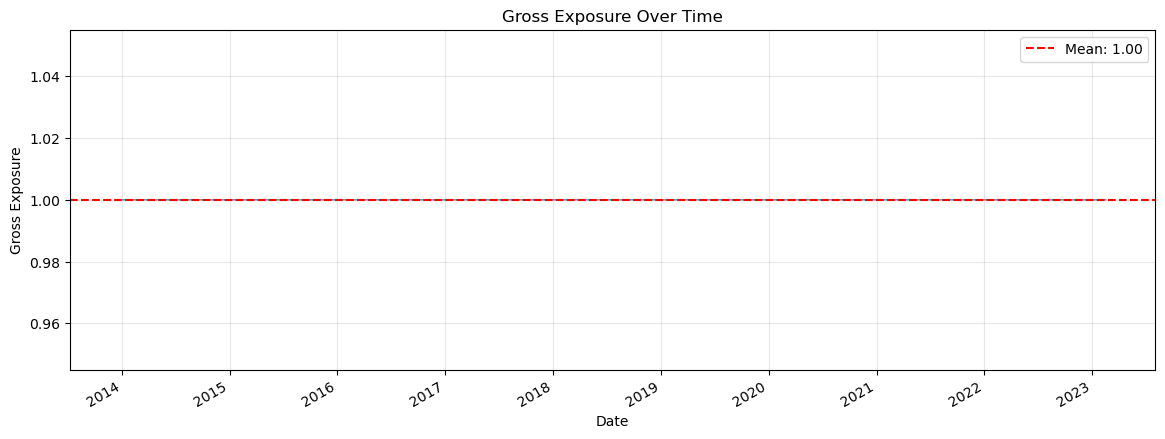

In [24]:
# Gross exposure over time
gross_exposure = weights.abs().sum(axis=1).round(6)

plt.figure(figsize=(14, 5))
gross_exposure.plot(linewidth=0.8)
plt.axhline(
    y=gross_exposure.mean(),
    color="r",
    linestyle="--",
    label=f"Mean: {gross_exposure.mean():.2f}",
)
plt.xlabel("Date")
plt.ylabel("Gross Exposure")
plt.title("Gross Exposure Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

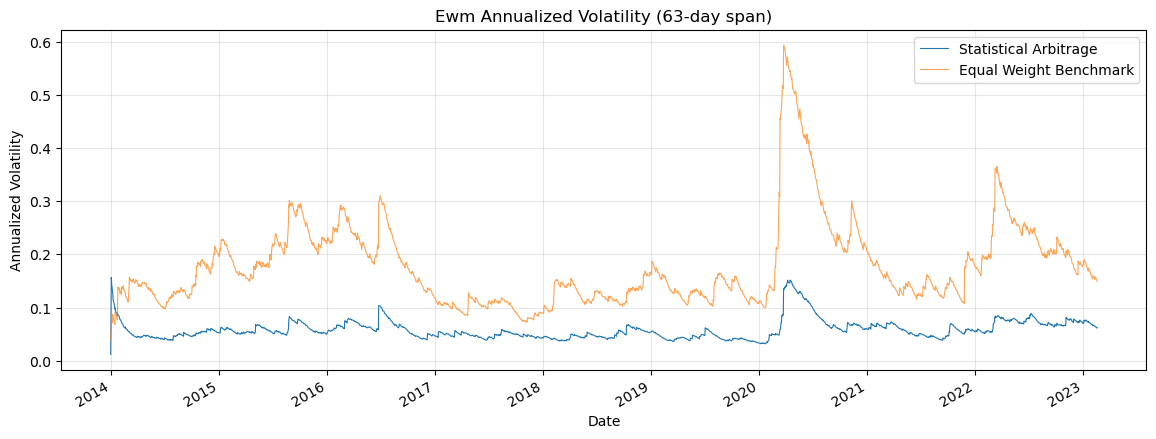

In [25]:
# Ewm volatility of strategy returns
strategy_returns = cumulative_returns.pct_change().dropna()
ewm_vol = strategy_returns.ewm(span=63).std() * np.sqrt(252)

benchmark_returns = equal_weight_benchmark.pct_change().dropna()
benchmark_ewm_vol = benchmark_returns.ewm(span=63).std() * np.sqrt(252)

plt.figure(figsize=(14, 5))
ewm_vol.plot(label="Statistical Arbitrage", linewidth=0.8)
benchmark_ewm_vol.plot(label="Equal Weight Benchmark", linewidth=0.8, alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("Ewm Annualized Volatility (63-day span)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. Sensitivity Analysis

## 6.1 Sensitivity to s-score entry threshold


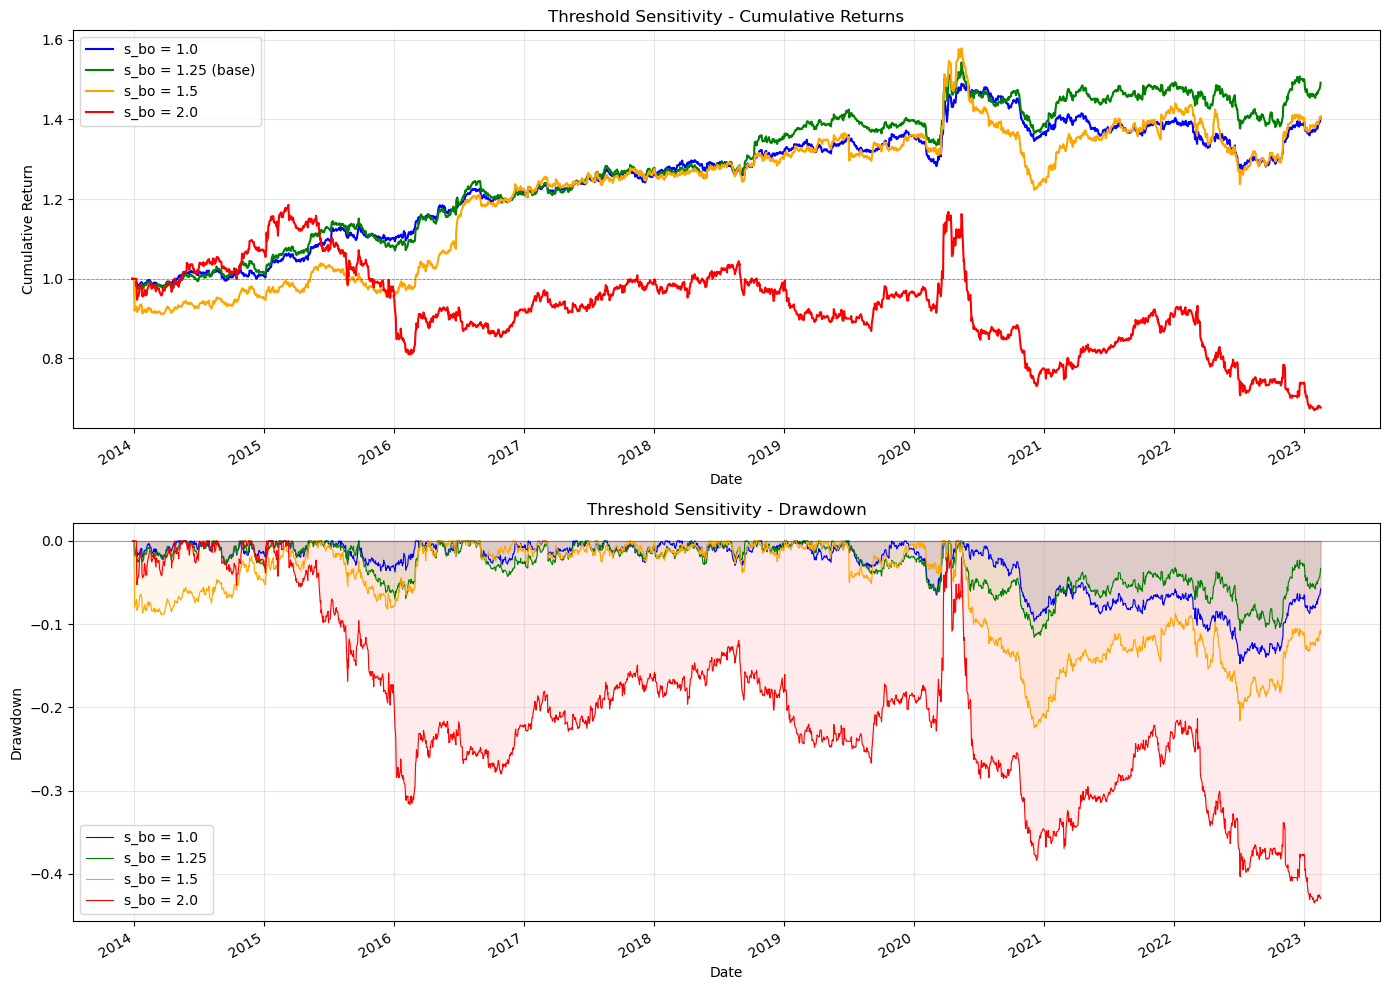

Threshold Sensitivity - Strategy Performance:
Metric                        s_bo=1.0    s_bo=1.25     s_bo=1.5     s_bo=2.0
-----------------------------------------------------------------------------
Total Return                    40.40%       49.23%       40.84%      -32.30%
Annualized Return                3.71%        4.40%        3.75%       -4.11%
Annualized Volatility            5.35%        6.06%        8.13%       13.48%
Sharpe Ratio                      0.69         0.73         0.46        -0.30
Maximum Drawdown               -14.75%      -11.59%      -22.49%      -43.49%


In [26]:
# Grid of opening thresholds to test in the sensitivity analysis.
s_bo_check = [1.0, 1.25, 1.5, 2.0]

# Dictionary that will store the cumulative return series for each opening threshold
sensitivity_curves = {}

# Dictionary that will store the summary performance statistics associated with each cumulative return curve.
sensitivity_stats = {}

# Loop over all entry thresholds.
for s in s_bo_check:

    # Dictionary that stores the full history of positions for the current threshold value.
    threshold_positions = {}

    # Dictionary representing the portfolio state at the current date.
    running_positions = {}

    # Loop over all rebalance dates
    for rebalance_date, params_today in all_ou_params.items():

        # Retrieve the vector of s-scores corresponding to the current rebalance date.
        scores_today = all_s_scores[rebalance_date]

        # Select only the assets with sufficiently fast mean reversion.
        valid_assets = [
            ticker
            for ticker, ticker_params in ou_params.items()
            if ticker_params["kappa"] > min_mean_reversion_speed
        ]

        # Update the portfolio positions using the current s-score vector and the threshold under consideration.
        running_positions = update_positions(
            current_positions=running_positions,
            cur_s_scores=scores_today,
            valid_assets=valid_assets,
            s_bo=s,
            s_so=s,
            s_bc=s_bc,
            s_sc=s_sc,
        )

        # Store the updated portfolio state at the current rebalance date.
        threshold_positions[rebalance_date] = running_positions.copy()

    # Convert the dictionary of position snapshots into a DataFrame:
    positions_panel = pd.DataFrame(threshold_positions).T.fillna(0.0)

    # Ensure the index is recognized as a datetime index and sorted chronologically, necessary for a correct time-series backtest.
    positions_panel.index = pd.to_datetime(positions_panel.index)
    positions_panel = positions_panel.sort_index()

    # Transform discrete trading signals into portfolio weights.
    weights_panel = compute_portfolio_weights(positions_panel)

    # Run the backtest with zero transaction costs.
    equity_curve = backtest(
        portfolios=weights_panel,
        returns=performance,
        transaction_costs=0.0,
    )

    # Save the cumulative return time series for the current threshold.
    sensitivity_curves[s] = equity_curve

    # Compute and store summary performance statistics
    sensitivity_stats[s] = compute_strategy_statistics(equity_curve.dropna())


fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Cumulative returns plot
ax1 = axes[0]

colors = {1.0: "blue", 1.25: "green", 1.5: "orange", 2.0: "red"}

for s in sorted(sensitivity_curves.keys()):
    cum = sensitivity_curves[s]
    label = f"s_bo = {s}" + (" (base)" if s == 1.25 else "")
    
    (cum / cum.iloc[0]).plot(
        ax=ax1,
        label=label,
        color=colors[s],
        linewidth=1.5
    )

ax1.axhline(1, color="black", linewidth=0.6, linestyle="--", alpha=0.4)
ax1.set_title("Threshold Sensitivity - Cumulative Returns")
ax1.set_xlabel("Date")
ax1.set_ylabel("Cumulative Return")
ax1.legend()
ax1.grid(alpha=0.3)

# Drawdown plot
ax2 = axes[1]

for s in sorted(sensitivity_curves.keys()):
    cum = sensitivity_curves[s]
    drawdown = (cum - cum.cummax()) / cum.cummax()

    drawdown.plot(
        ax=ax2,
        label=f"s_bo = {s}",
        color=colors[s],
        linewidth=0.8
    )

    ax2.fill_between(
        drawdown.index,
        0,
        drawdown.values,
        color=colors[s],
        alpha=0.08
    )

ax2.axhline(0, color="black", linewidth=0.6, alpha=0.4)
ax2.set_title("Threshold Sensitivity - Drawdown")
ax2.set_xlabel("Date")
ax2.set_ylabel("Drawdown")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Performance metrics for each threshold in a tabular format.
print("Threshold Sensitivity - Strategy Performance:")
print(f"{'Metric':<25} " + " ".join(f"{'s_bo='+str(s):>12}" for s in sorted(sensitivity_curves.keys())))
print("-" * (25 + 13 * len(sensitivity_curves)))

metrics = {}
for s, cum in sorted(sensitivity_curves.items()):
    metrics[s] = compute_strategy_statistics(cum.dropna())

for metric, label, fmt in [
    ("total_return",          "Total Return",          ".2%"),
    ("annualized_return",     "Annualized Return",     ".2%"),
    ("annualized_volatility", "Annualized Volatility", ".2%"),
    ("sharpe_ratio",          "Sharpe Ratio",          ".2f"),
    ("max_drawdown",          "Maximum Drawdown",      ".2%"),
]:
    values = " ".join(f"{metrics[s][metric]:>12{fmt}}" for s in sorted(sensitivity_curves.keys()))
    print(f"{label:<25} {values}")

## 6.2 Fixed factors vs variable factor selection


In [27]:
# Variance-explained targets
explained_variance_grid = [0.40, 0.55, 0.65, 0.75]

# Containers for the outputs of each scenario
dynamic_factor_counts = {}      
dynamic_weight_panels = {}      
dynamic_equity_curves = {}      
dynamic_performance_stats = {} 

# Set this flag depending on whether your modified s-score is implemented correctly.
use_modified_score = True

# Loop over all explained-variance targets
for variance_target in explained_variance_grid:

    # Dictionary collecting daily position for the current target
    target_position_history = {}

    # Dictionary representing the current state of the strategy
    today_positions = {}

    # Dictionary storing the number of PCA factors selected at each rebalance date
    selected_factor_count = {}

    # Loop over all dates in the return panel
    for trade_date in performance.index:

        # Build the rolling 252-day estimation window
        rolling_window, rolling_info = prepare_rolling_estimation_window(
            returns=performance,
            rebalance_date=trade_date,
            lookback=estimation_window,
            min_coverage=min_coverage,
            return_diagnostics=True,
        )

        # Skip dates with insufficient history or empty cross-section
        if (
            rolling_info["row_count"] < estimation_window
            or rolling_window.shape[1] == 0
        ):
            continue

        # Convert the timestamp to a plain date
        trade_day_key = trade_date.to_pydatetime().date()

        # If the factor model was not stored for this date, skip it
        if trade_day_key not in all_factor_models:
            continue

        # Retrieve eigenvalues from the previously stored PCA model and compute cumulative explained variance
        spectrum = all_factor_models[trade_day_key]["eigenvalues"]
        cumulative_variance = np.cumsum(spectrum) / spectrum.sum()

        # Select the minimum number of factors required to reach the target variance
        chosen_factor_number = int(np.searchsorted(cumulative_variance, variance_target) + 1)

        # Store the chosen number of factors for this date
        selected_factor_count[trade_day_key] = chosen_factor_number

        # Re-estimate the factor model using the selected number of factors
        rolling_factor_model = estimate_factor_model(
            rolling_window,
            n_factors=chosen_factor_number
        )

        # Estimate residuals on the O-U window and then cumulate them
        rolling_cum_residuals = estimate_ou_window_residuals(
            rolling_window,
            rolling_factor_model["factors"],
            ou_estimation_window
        )["residuals"].cumsum()

        # Estimate O-U parameters 
        rolling_ou_parameters = estimate_all_ou_parameters(
            rolling_cum_residuals,
            dt=1 / 252,
            center_ou_means=False,
        )

        # Keep only assets with sufficiently fast mean reversion
        valid_assets_var = [
            ticker
            for ticker, ticker_params in rolling_ou_parameters.items()
            if ticker_params["kappa"] > min_mean_reversion_speed
        ]

        # Compute S-scores
        for ticker, alpha_val in factor_model["alphas"].items():
            if ticker in rolling_ou_parameters:
                rolling_ou_parameters[ticker]["alphas"] = alpha_val

        # Compute the s-scores for the current cross-section
        rolling_scores = compute_s_score(
            rolling_cum_residuals,
            rolling_ou_parameters,
            use_modified_score
        )

        # Skip if the score panel is empty
        if rolling_scores.empty:
            continue

        # Extract the current-day s-score vector
        latest_scores = rolling_scores.iloc[-1]

        # Update trading positions according to the strategy rules
        today_positions = update_positions(
            current_positions=today_positions,
            cur_s_scores=latest_scores,
            valid_assets=valid_assets_var,
            s_bo=s_bo,
            s_so=s_so,
            s_bc=s_bc,
            s_sc=s_sc,
        )

        # Save the current position state
        target_position_history[trade_day_key] = today_positions.copy()

    # Convert the position history into a DataFrame
    signal_matrix = pd.DataFrame(target_position_history).T

    # Make sure the index is a proper datetime index
    signal_matrix.index = pd.to_datetime(signal_matrix.index)

    # Replace missing entries with zero (flat position)
    signal_matrix = signal_matrix.fillna(0.0)

    # Convert signals into equal-weight portfolio weights
    portfolio_matrix = compute_portfolio_weights(signal_matrix)

    # Run the backtest 
    cumulative_pnl = backtest(
        portfolios=portfolio_matrix,
        returns=performance,
        transaction_costs=0.0,
    )

    # Compute summary statistics
    performance_summary = compute_strategy_statistics(cumulative_pnl.dropna())

    # Store outputs for this target
    dynamic_factor_counts[variance_target] = selected_factor_count
    dynamic_weight_panels[variance_target] = portfolio_matrix
    dynamic_equity_curves[variance_target] = cumulative_pnl
    dynamic_performance_stats[variance_target] = performance_summary
    print(
        f"Variable Factor Strategy Performance ({variance_target * 100:.0f}% target variance):"
    )
    print(f"  Total Return: {performance_summary['total_return']:.2%}")
    print(f"  Annualized Return: {performance_summary['annualized_return']:.2%}")
    print(f"  Annualized Volatility: {performance_summary['annualized_volatility']:.2%}")
    print(f"  Sharpe Ratio: {performance_summary['sharpe_ratio']:.2f}")
    print(f"  Maximum Drawdown: {performance_summary['max_drawdown']:.2%}")
    print("-" * 50)


Variable Factor Strategy Performance (40% target variance):
  Total Return: 68.34%
  Annualized Return: 5.76%
  Annualized Volatility: 6.86%
  Sharpe Ratio: 0.84
  Maximum Drawdown: -15.24%
--------------------------------------------------
Variable Factor Strategy Performance (55% target variance):
  Total Return: 74.65%
  Annualized Return: 6.18%
  Annualized Volatility: 6.50%
  Sharpe Ratio: 0.95
  Maximum Drawdown: -8.93%
--------------------------------------------------
Variable Factor Strategy Performance (65% target variance):
  Total Return: 55.57%
  Annualized Return: 4.86%
  Annualized Volatility: 6.07%
  Sharpe Ratio: 0.80
  Maximum Drawdown: -10.28%
--------------------------------------------------
Variable Factor Strategy Performance (75% target variance):
  Total Return: 53.43%
  Annualized Return: 4.71%
  Annualized Volatility: 5.80%
  Sharpe Ratio: 0.81
  Maximum Drawdown: -7.71%
--------------------------------------------------


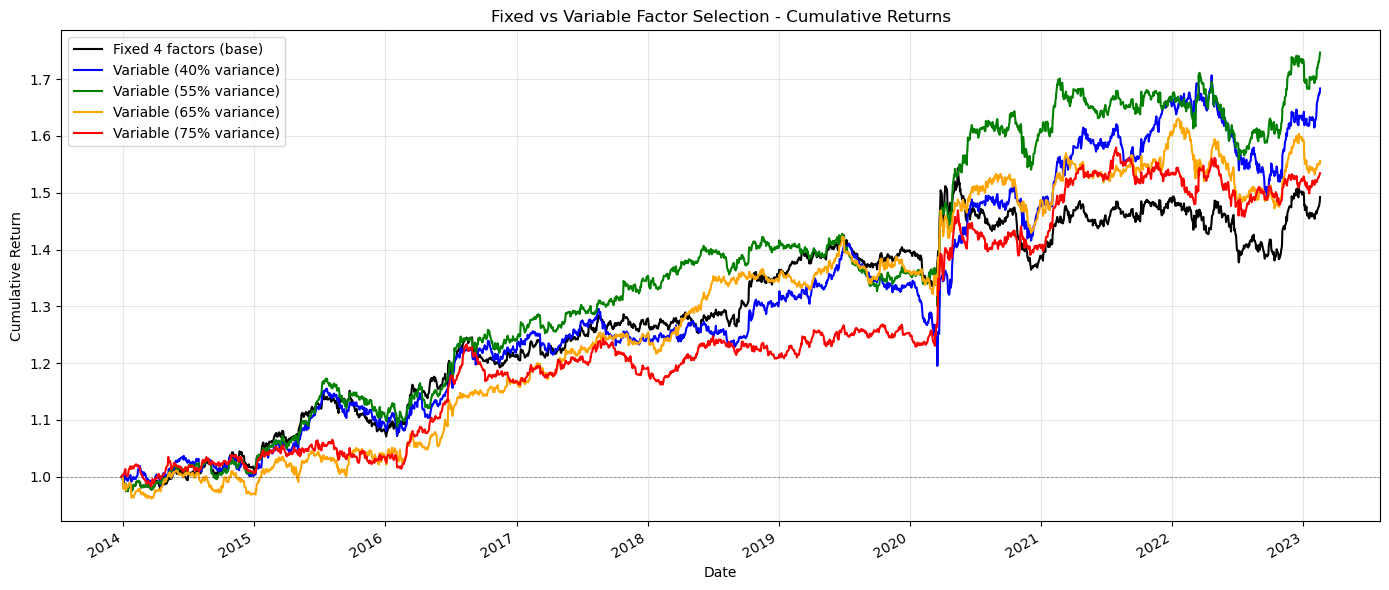

In [28]:
plt.figure(figsize=(14, 6))
ax1 = plt.gca()

var_colors = {0.40: "blue", 0.55: "green", 0.65: "orange", 0.75: "red"}

# Fixed-factor benchmark
(cumulative_returns / cumulative_returns.iloc[0]).plot(
    ax=ax1,
    label=f"Fixed {n_factors} factors (base)",
    color="black",
    linewidth=1.5
)

# Variable-factor strategies
for variance_target in sorted(dynamic_equity_curves.keys()):
    equity_curve = dynamic_equity_curves[variance_target]
    label = f"Variable ({variance_target * 100:.0f}% variance)"
    
    (equity_curve / equity_curve.iloc[0]).plot(
        ax=ax1,
        label=label,
        color=var_colors[variance_target],
        linewidth=1.5
    )

ax1.axhline(1, color="black", linewidth=0.6, linestyle="--", alpha=0.4)
ax1.set_title("Fixed vs Variable Factor Selection - Cumulative Returns")
ax1.set_xlabel("Date")
ax1.set_ylabel("Cumulative Return")
ax1.legend()
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 7 Trading Time: Volume-Adjusted Returns

### Trading Time

The paper proposes measuring returns in **trading time** rather than calendar time.
The idea: price moves on low-volume days carry more information than moves on high-volume days.

The adjusted return:

$$\bar{R}_{i,t} = R_{i,t} \cdot \frac{\langle \delta V_i \rangle}{V_{i,t}}$$

where $\langle \delta V_i \rangle$ is the trailing average daily volume and $V_{i,t}$ is the actual volume on day $t$.

This amplifies price moves on quiet days and dampens moves on heavy-volume days.
We run the full backtest pipeline on these adjusted returns and compare to calendar time.


In [29]:
# Compute volume-adjusted returns
vol_adjusted_returns = compute_volume_adjusted_returns(
    returns=performance,
    volume=volume,
)

# Drop NaN rows
vol_adjusted_returns = vol_adjusted_returns.dropna(how="all")

print(f"Calendar-time returns shape: {performance.shape}")
print(f"Volume-adjusted returns shape: {vol_adjusted_returns.shape}")

# Print the number of rows dropped due to NaNs
n_dropped_rows = performance.shape[0] - vol_adjusted_returns.shape[0]
print(f"Dropped {n_dropped_rows} rows due to NaNs in volume-adjusted returns.")

Calendar-time returns shape: (2598, 50)
Volume-adjusted returns shape: (2539, 50)
Dropped 59 rows due to NaNs in volume-adjusted returns.


In [30]:
# Run backtest on volume-adjusted (trading-time) returns
tt_position_history: dict = {}
tt_active_positions: dict[str, float] = {}

var_tgt = None # Set to a value in explained_variance_grid to use variable factor selection, or None to use fixed n_factors

use_variable_factors = var_tgt is not None
baseline_cumulative_returns = dynamic_equity_curves[var_tgt] if use_variable_factors else cumulative_returns

for date in vol_adjusted_returns.index:

    # Build rolling estimation window on trading-time returns
    tt_window, tt_diagnostics = prepare_rolling_estimation_window(
        returns=vol_adjusted_returns,
        rebalance_date=date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if tt_diagnostics["row_count"] < estimation_window or tt_window.shape[1] == 0:
        continue

    date_key = date.to_pydatetime().date()

    # Determine the number of PCA factors to use
    if use_variable_factors:
        eigen_spectrum  = all_factor_models[date_key]["eigenvalues"]
        cumvar          = np.cumsum(eigen_spectrum) / eigen_spectrum.sum()
        n_factors_today = int(np.searchsorted(cumvar, var_tgt) + 1)
    else:
        n_factors_today = n_factors

    # Step 1 — factor model on trading-time returns
    tt_factor_model = estimate_factor_model(tt_window, n_factors=n_factors_today)

    # Step 2 — OLS on the 60-day sub-window, then cumulate residuals
    tt_cum_residuals = estimate_ou_window_residuals(
        tt_window, tt_factor_model["factors"], ou_estimation_window
    )["residuals"].cumsum()

    # Step 3 — O-U parameter estimation
    tt_ou_params = estimate_all_ou_parameters(
        tt_cum_residuals, dt=1/252, center_ou_means=False
    )

    # Step 4 — kappa filter
    tt_valid_assets = [
        t for t, p in tt_ou_params.items()
        if p["kappa"] > min_mean_reversion_speed
    ]

    # Step 5 — inject alphas and compute modified s-scores
    for ticker, alpha_val in tt_factor_model["alphas"].items():
        if ticker in tt_ou_params:
            tt_ou_params[ticker]["alphas"] = alpha_val

    tt_s_scores = compute_s_score(tt_cum_residuals, tt_ou_params, modified=True).iloc[-1]

    # Step 6 — update positions
    tt_active_positions = update_positions(
        current_positions=tt_active_positions,
        cur_s_scores=tt_s_scores,
        valid_assets=tt_valid_assets,
        s_bo=s_bo, s_so=s_so, s_bc=s_bc, s_sc=s_sc,
    )
    tt_position_history[date_key] = tt_active_positions.copy()

# Build weight matrix — signals from trading time, PnL on calendar-time returns
tt_positions_df = pd.DataFrame(tt_position_history).T
tt_positions_df.index = pd.to_datetime(tt_positions_df.index)
tt_positions_df = tt_positions_df.fillna(0.0)

trading_time_weights  = compute_portfolio_weights(tt_positions_df)
trading_time_cumret   = backtest(trading_time_weights, performance)
trading_time_stats    = compute_strategy_statistics(trading_time_cumret.dropna())

print("Trading-Time Strategy Performance:")
print(f"  Total Return:          {trading_time_stats['total_return']:.2%}")
print(f"  Annualized Return:     {trading_time_stats['annualized_return']:.2%}")
print(f"  Annualized Volatility: {trading_time_stats['annualized_volatility']:.2%}")
print(f"  Sharpe Ratio:          {trading_time_stats['sharpe_ratio']:.2f}")
print(f"  Maximum Drawdown:      {trading_time_stats['max_drawdown']:.2%}")

Trading-Time Strategy Performance:
  Total Return:          58.81%
  Annualized Return:     5.23%
  Annualized Volatility: 6.07%
  Sharpe Ratio:          0.86
  Maximum Drawdown:      -12.32%


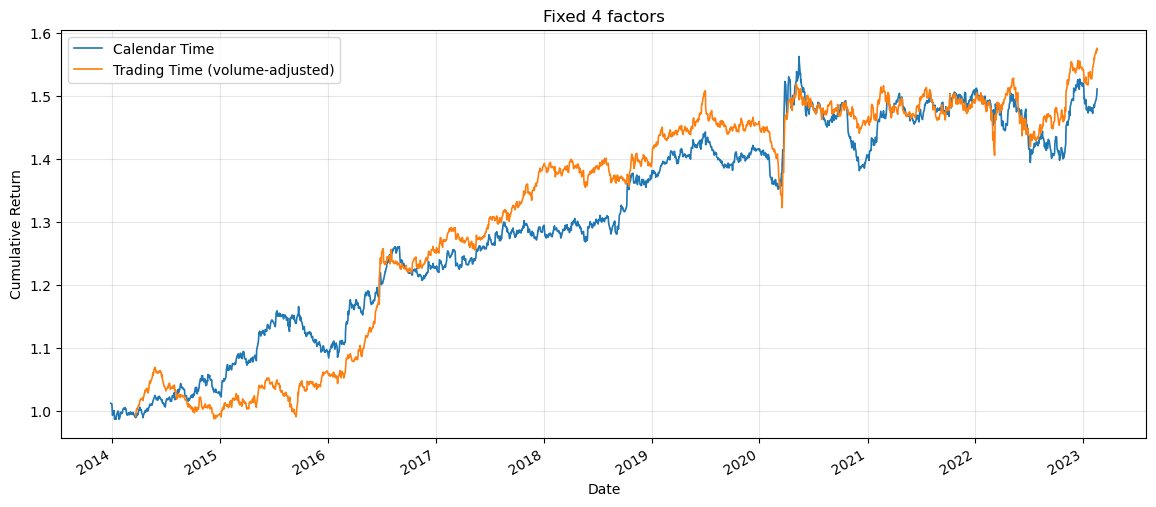


Strategy Comparison:
                      Calendar Time Trading Time
Total Return                 49.23%       58.81%
Annualized Return             4.40%        5.23%
Annualized Volatility         6.06%        6.07%
Sharpe Ratio                   0.73         0.86
Max Drawdown                -11.59%      -12.32%


In [31]:
# Compare calendar time vs trading time
title = (
    f"Variance Explained by n_factors w/ {var_tgt:.2%}"
    if var_tgt
    else f"Fixed {n_factors} factors"
)

fig, ax = plt.subplots(figsize=(14, 6))
baseline_cumulative_returns.plot(ax=ax, label="Calendar Time", linewidth=1.2)
trading_time_cumret.plot(ax=ax, label="Trading Time (volume-adjusted)", linewidth=1.2)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.set_title(title)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

comparison = pd.DataFrame(
    {
        "Calendar Time": stats,
        "Trading Time":  trading_time_stats,
    }
)
comparison.index = [k.replace("_", " ").title() for k in comparison.index]

# Format for display: iterate over rows so we can check the row label for "ratio"
comparison_display = comparison.copy().astype(str)
for row in comparison.index:
    fmt = "{:.2f}" if "ratio" in row.lower() else "{:.2%}"
    comparison_display.loc[row] = comparison.loc[row].map(fmt.format)

print("\nStrategy Comparison:")
print(comparison_display.to_string())